In [1]:
!pip install torchvision
!pip install kagglehub
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
from __future__ import unicode_literals
import argparse
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torchvision.utils as vutils
from torch.autograd import Variable
import os
import json
import kagglehub
import shutil
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = kagglehub.dataset_download("udaykalyansreenivasa/lsun-bedroom-64x64-10perc")

print("Path to dataset files:", path)
class FlatImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.files = [f for f in os.listdir(root) if f.endswith(".jpg")]
        # all_files = [f for f in os.listdir(root) if f.endswith(".jpg")]
        # self.files = all_files[:2000]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, self.files[idx])
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img  # no label

Path to dataset files: /kaggle/input/datasets/udaykalyansreenivasa/lsun-bedroom-64x64-10perc


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = FlatImageDataset(root=path, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)

print(len(dataset))
img = dataset[0]
print(img.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
image_size = 64
batch_size = 64
num_workers = 2
image_size = 64
nz = 100
ngf = 64
ndf = 64
nc = 3
n_extra_layers = 0

lrG = 0.00005
lrD = 0.00005
beta1 = 0.5
niter = 3
noBN = False
ngpu = 1 if torch.cuda.is_available() else 0
mlp_G = False
mlp_D = False
D_iters = 5
cuda =  torch.cuda.is_available()
adam = True
clamp_upper = 0.01
clamp_lower = -0.01

experiment = "samples"
os.makedirs(experiment, exist_ok=True)


303125
torch.Size([3, 64, 64])


In [4]:
class DCGAN_D(nn.Module):
    def __init__(self, isize, nz, nc, ndf, ngpu, n_extra_layers=0):
        super(DCGAN_D, self).__init__()
        self.ngpu = ngpu
        assert isize % 16 == 0, "isize has to be a multiple of 16"

        main = nn.Sequential()
        # input is nc x isize x isize
        main.add_module('initial:{0}-{1}:conv'.format(nc, ndf),
                        nn.Conv2d(nc, ndf, 4, 2, 1, bias=False))
        main.add_module('initial:{0}:relu'.format(ndf),
                        nn.LeakyReLU(0.2, inplace=True))
        csize, cndf = isize // 2, ndf

        # Extra layers
        for t in range(n_extra_layers):
            main.add_module('extra-layers-{0}:{1}:conv'.format(t, cndf),
                            nn.Conv2d(cndf, cndf, 3, 1, 1, bias=False))
            main.add_module('extra-layers-{0}:{1}:batchnorm'.format(t, cndf),
                            nn.BatchNorm2d(cndf))
            main.add_module('extra-layers-{0}:{1}:relu'.format(t, cndf),
                            nn.LeakyReLU(0.2, inplace=True))

        while csize > 4:
            in_feat = cndf
            out_feat = cndf * 2
            main.add_module('pyramid:{0}-{1}:conv'.format(in_feat, out_feat),
                            nn.Conv2d(in_feat, out_feat, 4, 2, 1, bias=False))
            main.add_module('pyramid:{0}:batchnorm'.format(out_feat),
                            nn.BatchNorm2d(out_feat))
            main.add_module('pyramid:{0}:relu'.format(out_feat),
                            nn.LeakyReLU(0.2, inplace=True))
            cndf = cndf * 2
            csize = csize / 2

        # state size. K x 4 x 4
        main.add_module('final:{0}-{1}:conv'.format(cndf, 1),
                        nn.Conv2d(cndf, 1, 4, 1, 0, bias=False))
        self.main = main


    def forward(self, input):
        if isinstance(input.data, torch.cuda.FloatTensor) and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)

        return output.view(input.size(0))  # 👈 correct

class DCGAN_G(nn.Module):
    def __init__(self, isize, nz, nc, ngf, ngpu, n_extra_layers=0):
        super(DCGAN_G, self).__init__()
        self.ngpu = ngpu
        assert isize % 16 == 0, "isize has to be a multiple of 16"

        cngf, tisize = ngf//2, 4
        while tisize != isize:
            cngf = cngf * 2
            tisize = tisize * 2

        main = nn.Sequential()
        # input is Z, going into a convolution
        main.add_module('initial:{0}-{1}:convt'.format(nz, cngf),
                        nn.ConvTranspose2d(nz, cngf, 4, 1, 0, bias=False))
        main.add_module('initial:{0}:batchnorm'.format(cngf),
                        nn.BatchNorm2d(cngf))
        main.add_module('initial:{0}:relu'.format(cngf),
                        nn.ReLU(True))

        csize, cndf = 4, cngf
        while csize < isize//2:
            main.add_module('pyramid:{0}-{1}:convt'.format(cngf, cngf//2),
                            nn.ConvTranspose2d(cngf, cngf//2, 4, 2, 1, bias=False))
            main.add_module('pyramid:{0}:batchnorm'.format(cngf//2),
                            nn.BatchNorm2d(cngf//2))
            main.add_module('pyramid:{0}:relu'.format(cngf//2),
                            nn.ReLU(True))
            cngf = cngf // 2
            csize = csize * 2

        # Extra layers
        for t in range(n_extra_layers):
            main.add_module('extra-layers-{0}:{1}:conv'.format(t, cngf),
                            nn.Conv2d(cngf, cngf, 3, 1, 1, bias=False))
            main.add_module('extra-layers-{0}:{1}:batchnorm'.format(t, cngf),
                            nn.BatchNorm2d(cngf))
            main.add_module('extra-layers-{0}:{1}:relu'.format(t, cngf),
                            nn.ReLU(True))

        main.add_module('final:{0}-{1}:convt'.format(cngf, nc),
                        nn.ConvTranspose2d(cngf, nc, 4, 2, 1, bias=False))
        main.add_module('final:{0}:tanh'.format(nc),
                        nn.Tanh())
        self.main = main

    def forward(self, input):
        if isinstance(input.data, torch.cuda.FloatTensor) and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output
###############################################################################



class MLP_G(nn.Module):
    def __init__(self, isize, nz, nc, ngf, ngpu):
        super(MLP_G, self).__init__()
        self.ngpu = ngpu

        main = nn.Sequential(
            # Z goes into a linear of size: ngf
            nn.Linear(nz, ngf),
            nn.ReLU(True),
            nn.Linear(ngf, ngf),
            nn.ReLU(True),
            nn.Linear(ngf, ngf),
            nn.ReLU(True),
            nn.Linear(ngf, nc * isize * isize),
        )
        self.main = main
        self.nc = nc
        self.isize = isize
        self.nz = nz

    def forward(self, input):
        input = input.view(input.size(0), input.size(1))
        if isinstance(input.data, torch.cuda.FloatTensor) and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output.view(output.size(0), self.nc, self.isize, self.isize)


class MLP_D(nn.Module):
    def __init__(self, isize, nz, nc, ndf, ngpu):
        super(MLP_D, self).__init__()
        self.ngpu = ngpu

        main = nn.Sequential(
            # Z goes into a linear of size: ndf
            nn.Linear(nc * isize * isize, ndf),
            nn.ReLU(True),
            nn.Linear(ndf, ndf),
            nn.ReLU(True),
            nn.Linear(ndf, ndf),
            nn.ReLU(True),
            nn.Linear(ndf, 1),
        )
        self.main = main
        self.nc = nc
        self.isize = isize
        self.nz = nz

    def forward(self, input):
        input = input.view(input.size(0), -1)

        if isinstance(input.data, torch.cuda.FloatTensor) and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)

        return output.view(input.size(0))  # 👈 per-sample output

In [5]:
def js_estimate(D_real, D_fake):
    return torch.mean(torch.log(D_real + 1e-8)) + \
           torch.mean(torch.log(1 - D_fake + 1e-8))

In [6]:
js_values_MLP = []

netG = MLP_G(image_size, nz, nc, ngf, ngpu).to(device)
netD = DCGAN_D(image_size, nz, nc, ndf, ngpu).to(device)
criterion = nn.BCEWithLogitsLoss()

optimizerD = optim.Adam(netD.parameters(), lr=lrD, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lrG, betas=(0.5, 0.999))

for epoch in range(niter):
    for i, data in enumerate(dataloader):

        if isinstance(data, (list, tuple)):
            real = data[0]
        else:
            real = data

        real = real.to(device)
        b_size = real.size(0)

        # --- Train D ---
        netD.zero_grad()

        label_real = torch.full((b_size,), 1.0, device=device)
        output_real = netD(real).view(-1)

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)

        label_fake = torch.full((b_size,), 0.0, device=device)
        output_fake = netD(fake.detach()).view(-1)

        lossD_real = criterion(output_real, label_real)
        lossD_fake = criterion(output_fake, label_fake)
        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # --- Train G ---
        netG.zero_grad()
        label_gen = torch.full((b_size,), 1.0, device=device)

        output = netD(fake).view(-1)
        lossG = criterion(output, label_gen)
        lossG.backward()
        optimizerG.step()

        D_real = torch.sigmoid(output_real)
        D_fake = torch.sigmoid(output_fake)

        js = (torch.mean(torch.log(D_real + 1e-8)) + torch.mean(torch.log(1 - D_fake + 1e-8))) / 2
        js +=np.log(4)
        js_values_MLP.append(js.item())
        if i % 50 == 0:  # print every 50 steps to avoid spam
            print(
                f"[Epoch {epoch}/{niter}] "
                f"[Step {i}] "
                f"Loss_D: {lossD.item():.4f} "
                f"(Real: {lossD_real.item():.4f}, Fake: {lossD_fake.item():.4f}) "
                f"Loss_G: {lossG.item():.4f} "
                f"JS: {js.item():.4f}"
            )

[Epoch 0/3] [Step 0] Loss_D: 1.1842 (Real: 0.6018, Fake: 0.5823) Loss_G: 3.7685 JS: 0.7942
[Epoch 0/3] [Step 50] Loss_D: 0.0098 (Real: 0.0066, Fake: 0.0032) Loss_G: 6.0817 JS: 1.3814
[Epoch 0/3] [Step 100] Loss_D: 0.0061 (Real: 0.0029, Fake: 0.0031) Loss_G: 6.4250 JS: 1.3833
[Epoch 0/3] [Step 150] Loss_D: 0.0047 (Real: 0.0023, Fake: 0.0025) Loss_G: 6.6735 JS: 1.3839
[Epoch 0/3] [Step 200] Loss_D: 0.0030 (Real: 0.0014, Fake: 0.0016) Loss_G: 7.1598 JS: 1.3848
[Epoch 0/3] [Step 250] Loss_D: 0.0031 (Real: 0.0013, Fake: 0.0017) Loss_G: 7.1126 JS: 1.3848
[Epoch 0/3] [Step 300] Loss_D: 0.0022 (Real: 0.0011, Fake: 0.0011) Loss_G: 7.4531 JS: 1.3852
[Epoch 0/3] [Step 350] Loss_D: 0.0021 (Real: 0.0010, Fake: 0.0012) Loss_G: 7.4638 JS: 1.3852
[Epoch 0/3] [Step 400] Loss_D: 0.0020 (Real: 0.0008, Fake: 0.0012) Loss_G: 7.5231 JS: 1.3853
[Epoch 0/3] [Step 450] Loss_D: 0.0016 (Real: 0.0008, Fake: 0.0008) Loss_G: 7.8342 JS: 1.3855
[Epoch 0/3] [Step 500] Loss_D: 0.0017 (Real: 0.0007, Fake: 0.0010) Loss_G

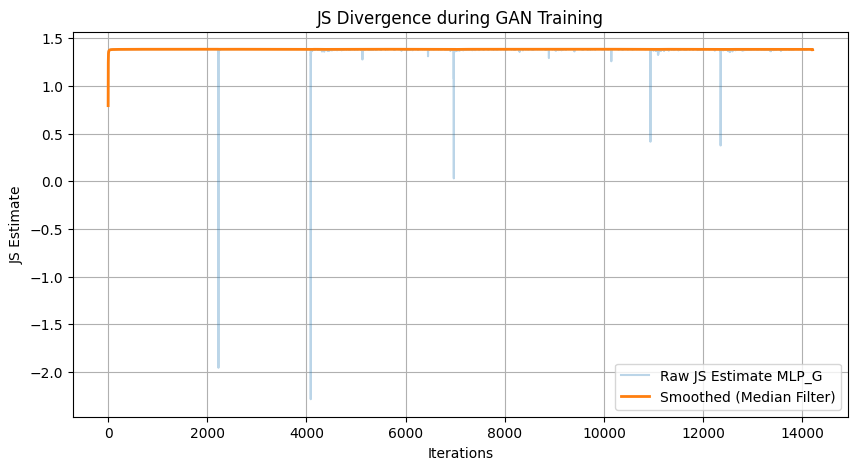

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import medfilt

# Convert to numpy
js_array = np.array(js_values_MLP)

# Apply median filter (paper-style smoothing)
js_smooth = medfilt(js_array, kernel_size=101)

plt.figure(figsize=(10,5))

plt.plot(js_array, alpha=0.3, label="Raw JS Estimate MLP_G")
plt.plot(js_smooth, linewidth=2, label="Smoothed (Median Filter)")

plt.xlabel("Iterations")
plt.ylabel("JS Estimate")
plt.title("JS Divergence during GAN Training")
plt.legend()
plt.grid(True)

# 💾 SAVE IMAGE
plt.savefig("MLP_G.png", dpi=300, bbox_inches="tight")

plt.show()

In [8]:
js_values_DCGAN = []

netG = DCGAN_G(image_size, nz, nc, ngf, ngpu).to(device)
netD = DCGAN_D(image_size, nz, nc, ndf, ngpu).to(device)
criterion = nn.BCEWithLogitsLoss()

optimizerD = optim.Adam(netD.parameters(), lr=lrD, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lrG, betas=(0.5, 0.999))

for epoch in range(niter):
    for i, data in enumerate(dataloader):

        if isinstance(data, (list, tuple)):
            real = data[0]
        else:
            real = data

        real = real.to(device)
        b_size = real.size(0)

        # --- Train D ---
        netD.zero_grad()

        label_real = torch.full((b_size,), 1.0, device=device)
        output_real = netD(real).view(-1)

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)

        label_fake = torch.full((b_size,), 0.0, device=device)
        output_fake = netD(fake.detach()).view(-1)

        lossD_real = criterion(output_real, label_real)
        lossD_fake = criterion(output_fake, label_fake)
        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # --- Train G ---
        netG.zero_grad()
        label_gen = torch.full((b_size,), 1.0, device=device)

        output = netD(fake).view(-1)
        lossG = criterion(output, label_gen)
        lossG.backward()
        optimizerG.step()

        D_real = torch.sigmoid(output_real)
        D_fake = torch.sigmoid(output_fake)

        js = (torch.mean(torch.log(D_real + 1e-8)) + torch.mean(torch.log(1 - D_fake + 1e-8))) / 2
        js += np.log(4)
        js_values_DCGAN.append(js.item())
        if i % 50 == 0:  # print every 50 steps to avoid spam
            print(
                f"[Epoch {epoch}/{niter}] "
                f"[Step {i}] "
                f"Loss_D: {lossD.item():.4f} "
                f"(Real: {lossD_real.item():.4f}, Fake: {lossD_fake.item():.4f}) "
                f"Loss_G: {lossG.item():.4f} "
                f"JS: {js.item():.4f}"
            )

[Epoch 0/3] [Step 0] Loss_D: 1.4611 (Real: 0.9142, Fake: 0.5468) Loss_G: 1.3315 JS: 0.6558
[Epoch 0/3] [Step 50] Loss_D: 0.1272 (Real: 0.0600, Fake: 0.0672) Loss_G: 4.6387 JS: 1.3227
[Epoch 0/3] [Step 100] Loss_D: 0.0442 (Real: 0.0191, Fake: 0.0251) Loss_G: 5.6938 JS: 1.3642
[Epoch 0/3] [Step 150] Loss_D: 0.0380 (Real: 0.0144, Fake: 0.0236) Loss_G: 6.7415 JS: 1.3673
[Epoch 0/3] [Step 200] Loss_D: 0.0290 (Real: 0.0151, Fake: 0.0139) Loss_G: 6.4825 JS: 1.3718
[Epoch 0/3] [Step 250] Loss_D: 0.0256 (Real: 0.0122, Fake: 0.0134) Loss_G: 7.2028 JS: 1.3735
[Epoch 0/3] [Step 300] Loss_D: 0.0176 (Real: 0.0120, Fake: 0.0057) Loss_G: 6.5834 JS: 1.3775
[Epoch 0/3] [Step 350] Loss_D: 0.0812 (Real: 0.0642, Fake: 0.0169) Loss_G: 4.9631 JS: 1.3457
[Epoch 0/3] [Step 400] Loss_D: 0.1505 (Real: 0.0910, Fake: 0.0595) Loss_G: 4.3959 JS: 1.3111
[Epoch 0/3] [Step 450] Loss_D: 0.0816 (Real: 0.0753, Fake: 0.0063) Loss_G: 4.3930 JS: 1.3455
[Epoch 0/3] [Step 500] Loss_D: 0.0900 (Real: 0.0649, Fake: 0.0252) Loss_G

In [9]:
print(len(js_values_DCGAN))
print(len(js_values_MLP))

14211
14211


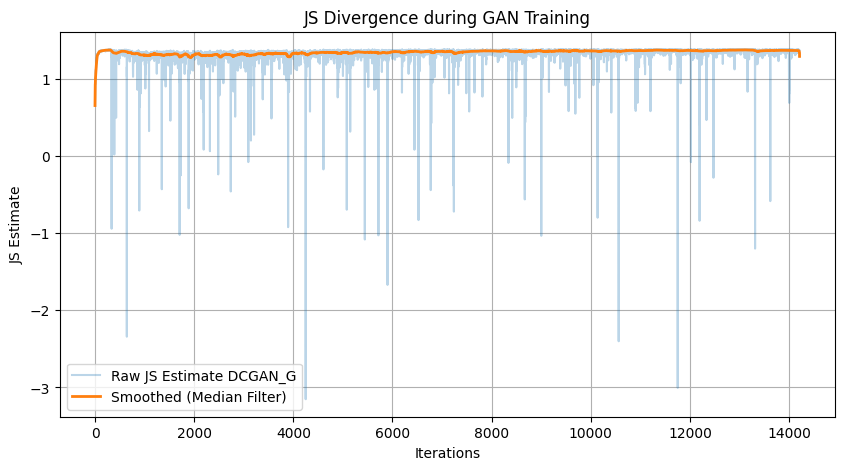

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import medfilt

# Convert to numpy
js_array = np.array(js_values_DCGAN)

# Apply median filter (window size = 101 like papers often use)
js_smooth = medfilt(js_array, kernel_size=101)

plt.figure(figsize=(10,5))

plt.plot(js_array, alpha=0.3, label="Raw JS Estimate DCGAN_G")
plt.plot(js_smooth, linewidth=2, label="Smoothed (Median Filter)")

plt.xlabel("Iterations")
plt.ylabel("JS Estimate")
plt.title("JS Divergence during GAN Training")
plt.legend()
plt.grid(True)

plt.savefig("DCGAN_G.png", dpi=300, bbox_inches="tight")

plt.show()

In [11]:
js_values_MLP_MLP = []

netG = MLP_G(image_size, nz, nc, ngf, ngpu).to(device)
netD = MLP_D(image_size, nz, nc, ndf, ngpu).to(device)
criterion = nn.BCEWithLogitsLoss()

optimizerD = optim.Adam(netD.parameters(), lr=lrD, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lrG, betas=(0.5, 0.999))

for epoch in range(niter):
    for i, data in enumerate(dataloader):

        if isinstance(data, (list, tuple)):
            real = data[0]
        else:
            real = data

        real = real.to(device)
        b_size = real.size(0)

        # --- Train D ---
        netD.zero_grad()

        label_real = torch.full((b_size,), 1.0, device=device)
        output_real = netD(real).view(-1)

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)

        label_fake = torch.full((b_size,), 0.0, device=device)
        output_fake = netD(fake.detach()).view(-1)

        lossD_real = criterion(output_real, label_real)
        lossD_fake = criterion(output_fake, label_fake)
        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # --- Train G ---
        netG.zero_grad()
        label_gen = torch.full((b_size,), 1.0, device=device)

        output = netD(fake).view(-1)
        lossG = criterion(output, label_gen)
        lossG.backward()
        optimizerG.step()

        D_real = torch.sigmoid(output_real)
        D_fake = torch.sigmoid(output_fake)

        js = (torch.mean(torch.log(D_real + 1e-8)) + torch.mean(torch.log(1 - D_fake + 1e-8))) / 2
        js += np.log(4)
        js_values_MLP_MLP.append(js.item())
        if i % 50 == 0:  # print every 50 steps to avoid spam
            print(
                f"[Epoch {epoch}/{niter}] "
                f"[Step {i}] "
                f"Loss_D: {lossD.item():.4f} "
                f"(Real: {lossD_real.item():.4f}, Fake: {lossD_fake.item():.4f}) "
                f"Loss_G: {lossG.item():.4f} "
                f"JS: {js.item():.4f}"
            )

[Epoch 0/3] [Step 0] Loss_D: 1.3853 (Real: 0.6741, Fake: 0.7112) Loss_G: 0.6781 JS: 0.6936
[Epoch 0/3] [Step 50] Loss_D: 0.8371 (Real: 0.2758, Fake: 0.5613) Loss_G: 0.8513 JS: 0.9677
[Epoch 0/3] [Step 100] Loss_D: 0.5140 (Real: 0.1176, Fake: 0.3964) Loss_G: 1.1296 JS: 1.1293
[Epoch 0/3] [Step 150] Loss_D: 0.5425 (Real: 0.0698, Fake: 0.4727) Loss_G: 0.9999 JS: 1.1151
[Epoch 0/3] [Step 200] Loss_D: 0.5219 (Real: 0.0273, Fake: 0.4946) Loss_G: 0.9554 JS: 1.1254
[Epoch 0/3] [Step 250] Loss_D: 0.6557 (Real: 0.0355, Fake: 0.6202) Loss_G: 0.7781 JS: 1.0584
[Epoch 0/3] [Step 300] Loss_D: 0.5947 (Real: 0.0146, Fake: 0.5801) Loss_G: 0.8259 JS: 1.0889
[Epoch 0/3] [Step 350] Loss_D: 0.5834 (Real: 0.0078, Fake: 0.5755) Loss_G: 0.8315 JS: 1.0946
[Epoch 0/3] [Step 400] Loss_D: 0.6002 (Real: 0.0038, Fake: 0.5964) Loss_G: 0.8047 JS: 1.0862
[Epoch 0/3] [Step 450] Loss_D: 0.5946 (Real: 0.0228, Fake: 0.5718) Loss_G: 0.8365 JS: 1.0890
[Epoch 0/3] [Step 500] Loss_D: 0.5498 (Real: 0.0032, Fake: 0.5466) Loss_G

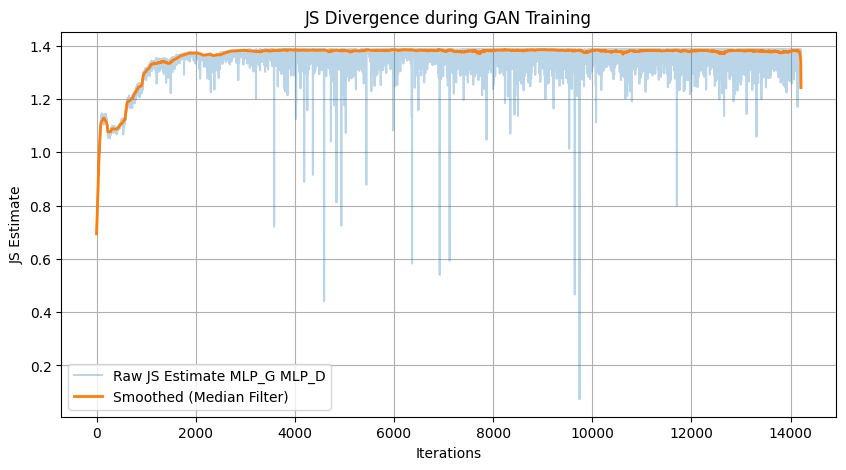

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import medfilt

# Convert to numpy
js_array = np.array(js_values_MLP_MLP)

# Apply median filter (window size = 101 like papers often use)
js_smooth = medfilt(js_array, kernel_size=101)

plt.figure(figsize=(10,5))

plt.plot(js_array, alpha=0.3, label="Raw JS Estimate MLP_G MLP_D")
plt.plot(js_smooth, linewidth=2, label="Smoothed (Median Filter)")

plt.xlabel("Iterations")
plt.ylabel("JS Estimate")
plt.title("JS Divergence during GAN Training")
plt.legend()
plt.grid(True)

plt.savefig("MLP_G_MLP_D.png", dpi=300, bbox_inches="tight")

plt.show()